Import all the library needed to clean and work on the data 

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

    Define all the paths that we are working on

In [6]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

medicare_path = RAW_DIR / "Medicare.csv"
iog_path = RAW_DIR / "IOG.xlsx"

print("BASE_DIR:", BASE_DIR)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

BASE_DIR: c:\Users\User\OneDrive\Desktop\MLProject
RAW_DIR: c:\Users\User\OneDrive\Desktop\MLProject\data\raw
PROCESSED_DIR: c:\Users\User\OneDrive\Desktop\MLProject\data\processed


Load the two datasets needed for our model and our project

In [7]:
medicare = pd.read_csv(medicare_path)
iog = pd.read_excel(iog_path)

print("Medicare shape:", medicare.shape)
print("IOG shape:", iog.shape)

display(medicare.head())
display(iog.head())

Medicare shape: (1259343, 11)
IOG shape: (82749, 18)


,Rndrng_NPI,Rndrng_Prvdr_City,Rndrng_Prvdr_Cntry,Rndrng_Prvdr_Type,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Tot_Mdcr_Stdzd_Amt
0,1003000126,Bethesda,US,Hospitalist,11,344,814.0,173087.77,78590.79,62198.36,56080.64
1,1003000134,Evanston,US,Pathology,19,2093,4839.0,726858.00,171256.75,127984.95,122195.53
2,1003000142,Toledo,US,Anesthesiology,46,325,1455.0,451425.00,155879.22,118122.12,119617.08
3,1003000423,Cleveland,US,Obstetrics & Gynecology,16,63,119.0,13785.00,6388.39,5230.52,5501.02
4,1003000480,Aurora,US,General Surgery,23,99,124.0,98271.00,20288.98,15794.97,15586.25


,LASTNAME,FIRSTNAME,MIDNAME,BUSNAME,GENERAL,SPECIALTY,UPIN,NPI,DOB,ADDRESS,CITY,STATE,ZIP,EXCLTYPE,EXCLDATE,REINDATE,WAIVERDATE,WVRSTATE
0,NaN,NaN,NaN,"#1 MARKETING SERVICE, INC",OTHER BUSINESS,SOBER HOME,NaN,0,NaN,239 BRIGHTON BEACH AVENUE,BROOKLYN,NY,11235,1128a1,20200319,0,0,NaN
1,NaN,NaN,NaN,"1 BEST CARE, INC",OTHER BUSINESS,HOME HEALTH AGENCY,NaN,0,NaN,"2161 UNIVERSITY AVENUE W, STE",SAINT PAUL,MN,55114,1128b5,20230518,0,0,NaN
2,NaN,NaN,NaN,101 FIRST CARE PHARMACY INC,OTHER BUSINESS,PHARMACY,NaN,1972902351,NaN,"C/O 609 W 191ST STREET, APT D",NEW YORK,NY,10040,1128b8,20220320,0,0,NaN
3,NaN,NaN,NaN,14 LAWRENCE AVE PHARMACY,PHARMACY,NaN,NaN,0,NaN,14 LAWRENCE AVENUE,SMITHTOWN,NY,11787,1128a1,19880830,0,0,NaN
4,NaN,NaN,NaN,143 MEDICAL EQUIPMENT CO,DME COMPANY,DME - OXYGEN,NaN,0,NaN,701 NW 36 AVENUE,MIAMI,FL,33125,1128b7,19970620,0,0,NaN


Clean column names


In [8]:
medicare.columns = medicare.columns.str.strip()
iog.columns = iog.columns.str.strip()

print("Medicare columns:")
print(medicare.columns.tolist())

print("\nIOG columns:")
print(iog.columns.tolist())

Medicare columns:
['Rndrng_NPI', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type', 'Tot_HCPCS_Cds', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Sbmtd_Chrg', 'Tot_Mdcr_Alowd_Amt', 'Tot_Mdcr_Pymt_Amt', 'Tot_Mdcr_Stdzd_Amt']

IOG columns:
['LASTNAME', 'FIRSTNAME', 'MIDNAME', 'BUSNAME', 'GENERAL', 'SPECIALTY', 'UPIN', 'NPI', 'DOB', 'ADDRESS', 'CITY', 'STATE', 'ZIP', 'EXCLTYPE', 'EXCLDATE', 'REINDATE', 'WAIVERDATE', 'WVRSTATE']


Keep only important Medicare columns

In [9]:
important_cols = [
    "Rndrng_NPI",
    "Rndrng_Prvdr_City",
    "Rndrng_Prvdr_Cntry",
    "Rndrng_Prvdr_Type",
    "Tot_HCPCS_Cds",
    "Tot_Benes",
    "Tot_Srvcs",
    "Tot_Sbmtd_Chrg",
    "Tot_Mdcr_Alowd_Amt",
    "Tot_Mdcr_Pymt_Amt",
    "Tot_Mdcr_Stdzd_Amt"
]

medicare = medicare[important_cols].copy()

print("Medicare shape after column selection:", medicare.shape)
display(medicare.head())

Medicare shape after column selection: (1259343, 11)


,Rndrng_NPI,Rndrng_Prvdr_City,Rndrng_Prvdr_Cntry,Rndrng_Prvdr_Type,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Tot_Mdcr_Stdzd_Amt
0,1003000126,Bethesda,US,Hospitalist,11,344,814.0,173087.77,78590.79,62198.36,56080.64
1,1003000134,Evanston,US,Pathology,19,2093,4839.0,726858.00,171256.75,127984.95,122195.53
2,1003000142,Toledo,US,Anesthesiology,46,325,1455.0,451425.00,155879.22,118122.12,119617.08
3,1003000423,Cleveland,US,Obstetrics & Gynecology,16,63,119.0,13785.00,6388.39,5230.52,5501.02
4,1003000480,Aurora,US,General Surgery,23,99,124.0,98271.00,20288.98,15794.97,15586.25


Remove duplicates and fix types

In [10]:
medicare = medicare.drop_duplicates().copy()

medicare["Rndrng_NPI"] = medicare["Rndrng_NPI"].astype(str).str.strip()

numeric_cols = [
    "Tot_HCPCS_Cds",
    "Tot_Benes",
    "Tot_Srvcs",
    "Tot_Sbmtd_Chrg",
    "Tot_Mdcr_Alowd_Amt",
    "Tot_Mdcr_Pymt_Amt",
    "Tot_Mdcr_Stdzd_Amt"
]

for col in numeric_cols:
    medicare[col] = pd.to_numeric(medicare[col], errors="coerce")

print("Shape after duplicate removal:", medicare.shape)
print("\nData types:")
print(medicare.dtypes)

Shape after duplicate removal: (1259343, 11)

Data types:
Rndrng_NPI             object
Rndrng_Prvdr_City      object
Rndrng_Prvdr_Cntry     object
Rndrng_Prvdr_Type      object
Tot_HCPCS_Cds           int64
Tot_Benes               int64
Tot_Srvcs             float64
Tot_Sbmtd_Chrg        float64
Tot_Mdcr_Alowd_Amt    float64
Tot_Mdcr_Pymt_Amt     float64
Tot_Mdcr_Stdzd_Amt    float64
dtype: object


Missing value inspection

In [11]:
missing_counts = medicare.isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0])

Series([], dtype: int64)

Create missingness flags before filling (this is a note for the model)

In [12]:
for col in numeric_cols:
    medicare[f"{col}_was_missing"] = medicare[col].isna().astype(int)

for col in ["Rndrng_Prvdr_City", "Rndrng_Prvdr_Cntry", "Rndrng_Prvdr_Type"]:
    medicare[f"{col}_was_missing"] = medicare[col].isna().astype(int)

Fill missing values

In [13]:
medicare["Rndrng_Prvdr_City"] = medicare["Rndrng_Prvdr_City"].fillna("Unknown")
medicare["Rndrng_Prvdr_Cntry"] = medicare["Rndrng_Prvdr_Cntry"].fillna("Unknown")
medicare["Rndrng_Prvdr_Type"] = medicare["Rndrng_Prvdr_Type"].fillna("Unknown")

for col in numeric_cols:
    medicare[col] = medicare[col].fillna(medicare[col].median())

print("Any missing values left?")
print(medicare.isna().sum().sum())

Any missing values left?
0


Remove impossible negative values

In [14]:
for col in numeric_cols:
    medicare = medicare[medicare[col] >= 0]

print("Shape after removing negative values:", medicare.shape)

Shape after removing negative values: (1259343, 21)


Basic fraud-oriented feature engineering

In [15]:
eps = 1e-6

medicare["payment_per_service"] = medicare["Tot_Mdcr_Pymt_Amt"] / (medicare["Tot_Srvcs"] + eps)
medicare["charge_to_payment_ratio"] = medicare["Tot_Sbmtd_Chrg"] / (medicare["Tot_Mdcr_Pymt_Amt"] + eps)
medicare["services_per_beneficiary"] = medicare["Tot_Srvcs"] / (medicare["Tot_Benes"] + eps)
medicare["allowed_to_submitted_ratio"] = medicare["Tot_Mdcr_Alowd_Amt"] / (medicare["Tot_Sbmtd_Chrg"] + eps)
medicare["standardized_to_payment_ratio"] = medicare["Tot_Mdcr_Stdzd_Amt"] / (medicare["Tot_Mdcr_Pymt_Amt"] + eps)
medicare["beneficiaries_per_hcpcs"] = medicare["Tot_Benes"] / (medicare["Tot_HCPCS_Cds"] + eps)
medicare["services_per_hcpcs"] = medicare["Tot_Srvcs"] / (medicare["Tot_HCPCS_Cds"] + eps)
medicare["submitted_per_beneficiary"] = medicare["Tot_Sbmtd_Chrg"] / (medicare["Tot_Benes"] + eps)
medicare["payment_per_beneficiary"] = medicare["Tot_Mdcr_Pymt_Amt"] / (medicare["Tot_Benes"] + eps)

Clip extreme mathematical explosions

In [16]:
clip_config = {
    "payment_per_service": 13000,
    "charge_to_payment_ratio": 100,
    "services_per_beneficiary": 100,
    "beneficiaries_per_hcpcs": 1000,
    "services_per_hcpcs": 1000,
    "submitted_per_beneficiary": 100000,
    "payment_per_beneficiary": 100000,
    "allowed_to_submitted_ratio": 5,
    "standardized_to_payment_ratio": 5
}

for col, upper_value in clip_config.items():
    medicare[col] = medicare[col].clip(lower=0, upper=upper_value)

Log-transform strong skewed variables

In [17]:
log_features = [
    "Tot_HCPCS_Cds",
    "Tot_Benes",
    "Tot_Srvcs",
    "Tot_Sbmtd_Chrg",
    "Tot_Mdcr_Alowd_Amt",
    "Tot_Mdcr_Pymt_Amt",
    "Tot_Mdcr_Stdzd_Amt",
    "payment_per_service",
    "charge_to_payment_ratio",
    "services_per_beneficiary",
    "submitted_per_beneficiary",
    "payment_per_beneficiary"
]

for col in log_features:
    medicare[f"log_{col}"] = np.log1p(medicare[col])

In [18]:
specialty_group = medicare.groupby("Rndrng_Prvdr_Type")

medicare["spec_median_services"] = specialty_group["Tot_Srvcs"].transform("median")
medicare["spec_median_benes"] = specialty_group["Tot_Benes"].transform("median")
medicare["spec_median_payment"] = specialty_group["Tot_Mdcr_Pymt_Amt"].transform("median")
medicare["spec_median_submitted"] = specialty_group["Tot_Sbmtd_Chrg"].transform("median")
medicare["spec_median_payment_per_service"] = specialty_group["payment_per_service"].transform("median")
medicare["spec_median_services_per_beneficiary"] = specialty_group["services_per_beneficiary"].transform("median")
medicare["spec_median_charge_to_payment_ratio"] = specialty_group["charge_to_payment_ratio"].transform("median")

medicare["services_vs_specialty"] = medicare["Tot_Srvcs"] / (medicare["spec_median_services"] + eps)
medicare["benes_vs_specialty"] = medicare["Tot_Benes"] / (medicare["spec_median_benes"] + eps)
medicare["payment_vs_specialty"] = medicare["Tot_Mdcr_Pymt_Amt"] / (medicare["spec_median_payment"] + eps)
medicare["submitted_vs_specialty"] = medicare["Tot_Sbmtd_Chrg"] / (medicare["spec_median_submitted"] + eps)
medicare["pps_vs_specialty"] = medicare["payment_per_service"] / (medicare["spec_median_payment_per_service"] + eps)
medicare["spb_vs_specialty"] = medicare["services_per_beneficiary"] / (medicare["spec_median_services_per_beneficiary"] + eps)
medicare["ctp_vs_specialty"] = medicare["charge_to_payment_ratio"] / (medicare["spec_median_charge_to_payment_ratio"] + eps)

Clip specialty comparison features

In [19]:
specialty_ratio_cols = [
    "services_vs_specialty",
    "benes_vs_specialty",
    "payment_vs_specialty",
    "submitted_vs_specialty",
    "pps_vs_specialty",
    "spb_vs_specialty",
    "ctp_vs_specialty"
]

for col in specialty_ratio_cols:
    medicare[col] = medicare[col].clip(lower=0, upper=100)

Add rarity indicators

In [20]:
provider_type_counts = medicare["Rndrng_Prvdr_Type"].value_counts()
country_counts = medicare["Rndrng_Prvdr_Cntry"].value_counts()

medicare["rare_provider_type"] = medicare["Rndrng_Prvdr_Type"].map(provider_type_counts).lt(100).astype(int)
medicare["rare_country"] = medicare["Rndrng_Prvdr_Cntry"].map(country_counts).lt(100).astype(int)

Quick EDA: raw numeric distributions

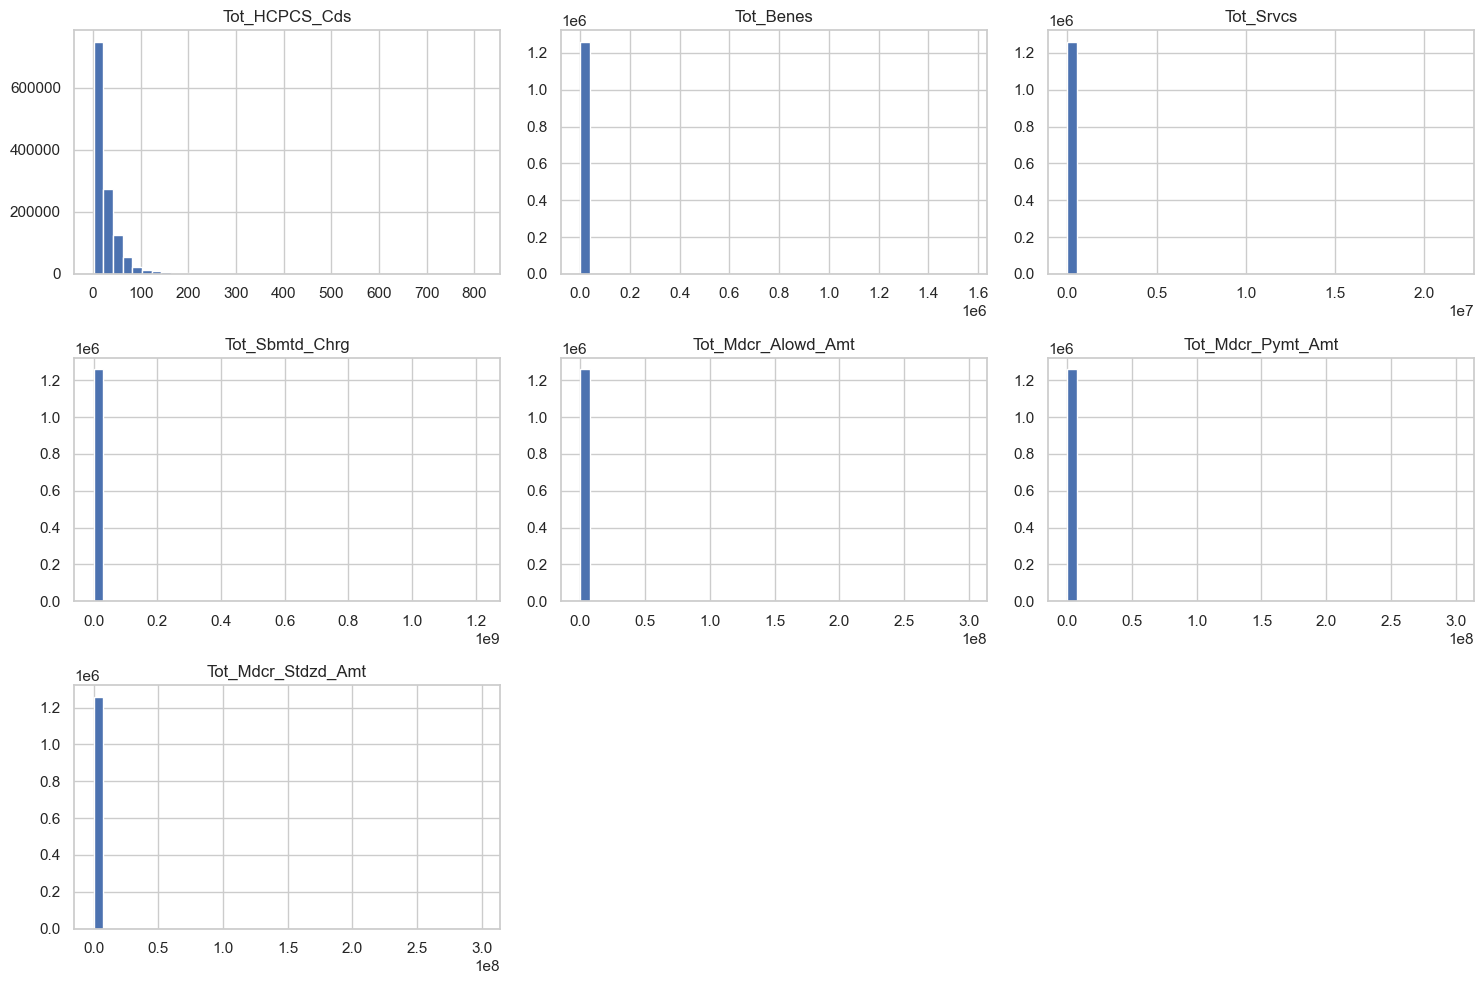

In [21]:
medicare[numeric_cols].hist(figsize=(15, 10), bins=40)
plt.tight_layout()
plt.show()

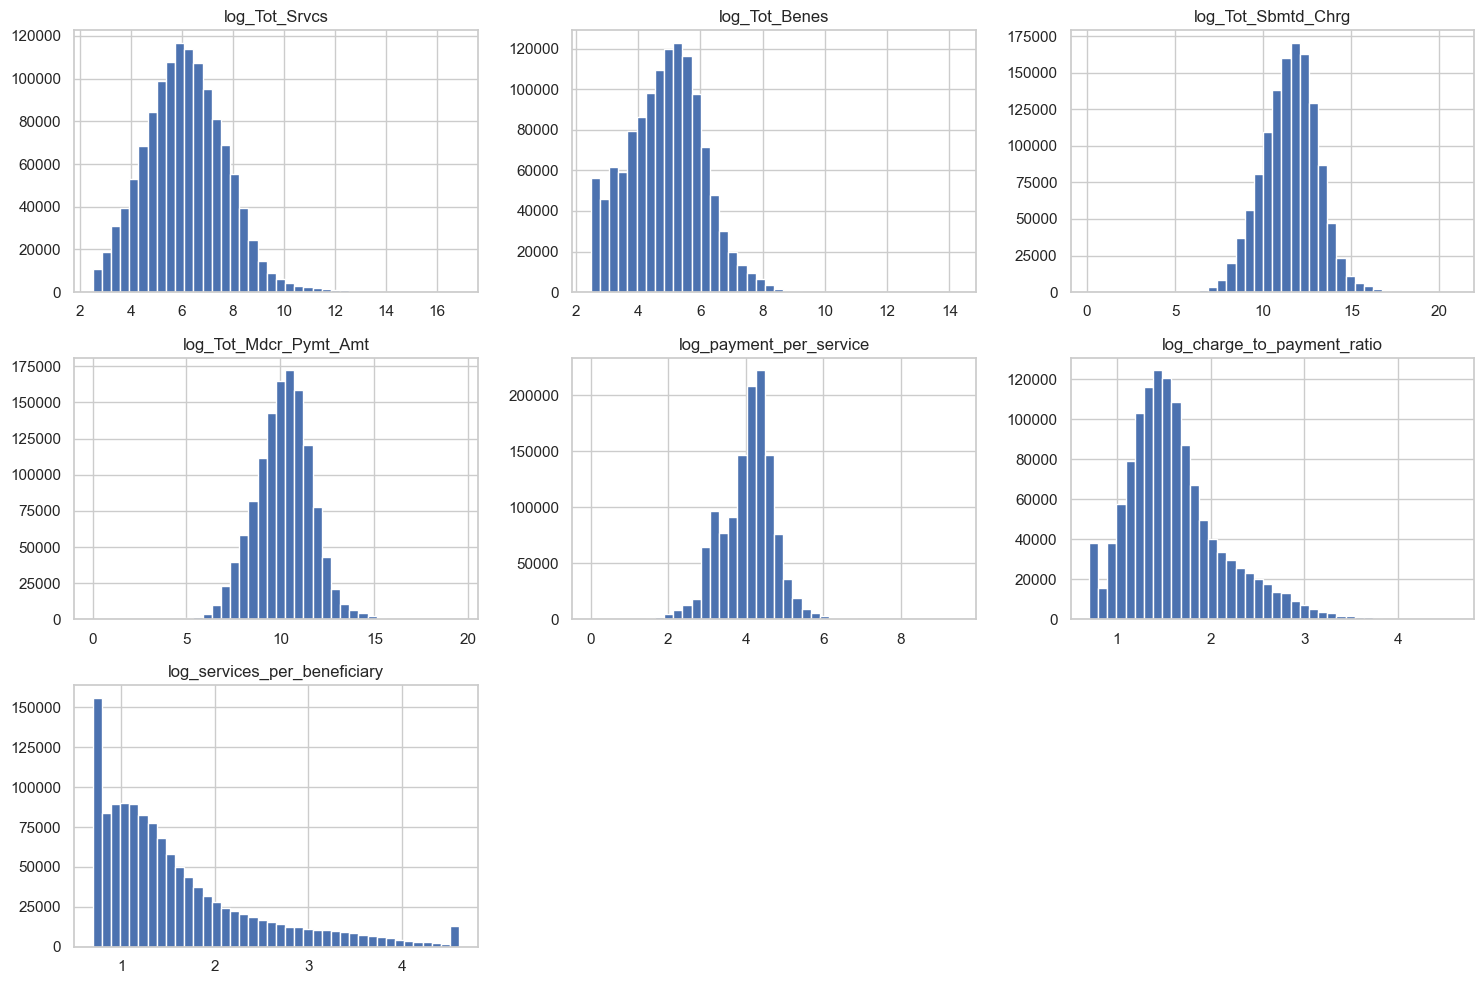

In [22]:
plot_cols = [
    "log_Tot_Srvcs",
    "log_Tot_Benes",
    "log_Tot_Sbmtd_Chrg",
    "log_Tot_Mdcr_Pymt_Amt",
    "log_payment_per_service",
    "log_charge_to_payment_ratio",
    "log_services_per_beneficiary"
]

medicare[plot_cols].hist(figsize=(15, 10), bins=40)
plt.tight_layout()
plt.show()

Boxplot for engineered features

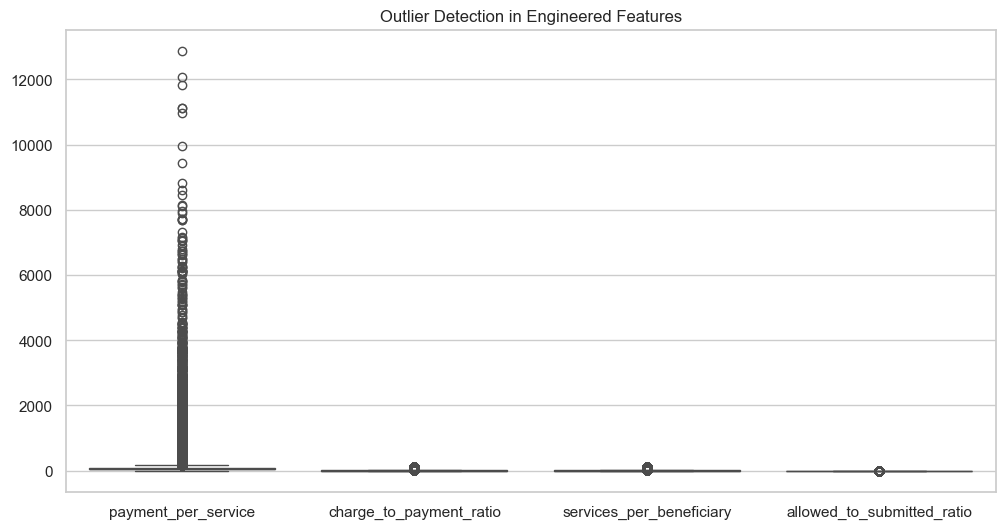

In [23]:
engineered_cols = [
    "payment_per_service",
    "charge_to_payment_ratio",
    "services_per_beneficiary",
    "allowed_to_submitted_ratio"
]

plt.figure(figsize=(12, 6))
sns.boxplot(data=medicare[engineered_cols])
plt.title("Outlier Detection in Engineered Features")
plt.show()

Charges vs payments scatter

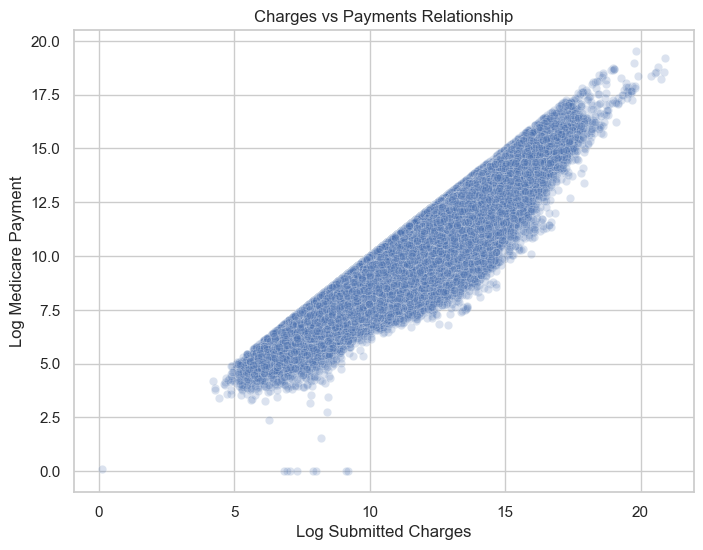

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=np.log1p(medicare["Tot_Sbmtd_Chrg"]),
    y=np.log1p(medicare["Tot_Mdcr_Pymt_Amt"]),
    alpha=0.2
)
plt.xlabel("Log Submitted Charges")
plt.ylabel("Log Medicare Payment")
plt.title("Charges vs Payments Relationship")
plt.show()

Provider behavior scatter

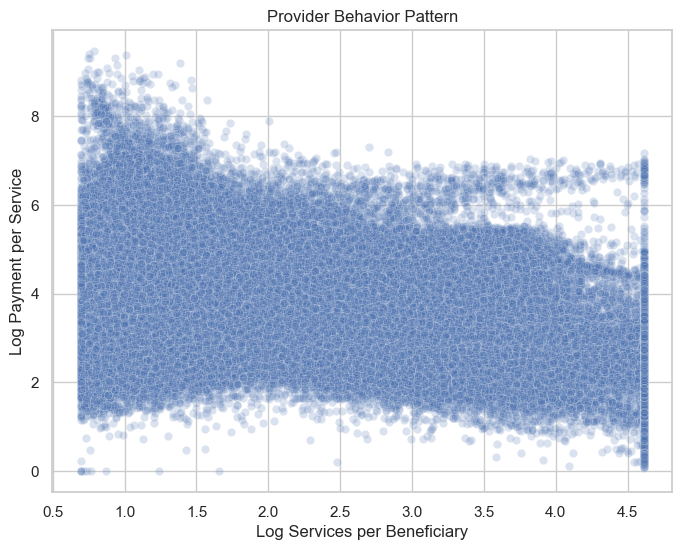

In [25]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=np.log1p(medicare["services_per_beneficiary"]),
    y=np.log1p(medicare["payment_per_service"]),
    alpha=0.2
)
plt.xlabel("Log Services per Beneficiary")
plt.ylabel("Log Payment per Service")
plt.title("Provider Behavior Pattern")
plt.show()

Clean Iog File

In [26]:
iog = iog.copy()

iog["NPI"] = iog["NPI"].astype(str).str.strip()
iog = iog[iog["NPI"].notna()].copy()
iog = iog[~iog["NPI"].isin(["", "0", "0.0", "nan", "None"])].copy()
iog = iog[iog["NPI"].str.fullmatch(r"\d{10}")].copy()

print("Valid IOG rows:", len(iog))
print("Unique excluded NPIs:", iog["NPI"].nunique())
display(iog.head())

Valid IOG rows: 8482
Unique excluded NPIs: 8306


,LASTNAME,FIRSTNAME,MIDNAME,BUSNAME,GENERAL,SPECIALTY,UPIN,NPI,DOB,ADDRESS,CITY,STATE,ZIP,EXCLTYPE,EXCLDATE,REINDATE,WAIVERDATE,WVRSTATE
2,NaN,NaN,NaN,101 FIRST CARE PHARMACY INC,OTHER BUSINESS,PHARMACY,NaN,1972902351,NaN,"C/O 609 W 191ST STREET, APT D",NEW YORK,NY,10040,1128b8,20220320,0,0,NaN
6,NaN,NaN,NaN,184TH STREET PHARMACY CORP,OTHER BUSINESS,PHARMACY,NaN,1922348218,NaN,69 E 184TH ST,BRONX,NY,10468,1128a1,20180419,0,0,NaN
26,NaN,NaN,NaN,"A & Y MEDICAL SUPPLY, INC",DME COMPANY,DME - GENERAL,NaN,1942476080,NaN,"6310 108TH STREET, APT 6J",FOREST HILLS,NY,11375,1128b8,20170518,0,0,NaN
30,NaN,NaN,NaN,"A CARING ALTERNATIVE, INC",OTHER BUSINESS,HOME HEALTH AGENCY,NaN,1275600959,NaN,"1229 HURON RD E, FLR 6TH",CLEVELAND,OH,44115,1128a1,20130320,0,0,NaN
33,NaN,NaN,NaN,"A FAIR DEAL PHARMACY, INC",OTHER BUSINESS,PHARMACY,NaN,1891731758,NaN,"C/O P O BOX 329014, #69709-05",BROOKLYN,NY,11232,1128b8,20170518,0,0,NaN


In [27]:
excluded_npis = set(iog["NPI"].unique())

medicare["fraud_label"] = medicare["Rndrng_NPI"].isin(excluded_npis).astype(int)

print("Fraud label counts:")
print(medicare["fraud_label"].value_counts())

print("\nFraud label ratios:")
print(medicare["fraud_label"].value_counts(normalize=True))

Fraud label counts:
fraud_label
0    1259156
1        187
Name: count, dtype: int64

Fraud label ratios:
fraud_label
0    0.999852
1    0.000148
Name: proportion, dtype: float64


Validate label overlap

In [28]:
matched = medicare[medicare["fraud_label"] == 1].copy()

matched_npis = set(matched["Rndrng_NPI"].unique())
overlap = set(medicare["Rndrng_NPI"]).intersection(excluded_npis)

print("Matched unique NPIs:", len(matched_npis))
print("Direct overlap count:", len(overlap))

display(matched.head())

Matched unique NPIs: 187
Direct overlap count: 187


,Rndrng_NPI,Rndrng_Prvdr_City,Rndrng_Prvdr_Cntry,Rndrng_Prvdr_Type,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Tot_Mdcr_Stdzd_Amt,Tot_HCPCS_Cds_was_missing,Tot_Benes_was_missing,Tot_Srvcs_was_missing,Tot_Sbmtd_Chrg_was_missing,Tot_Mdcr_Alowd_Amt_was_missing,Tot_Mdcr_Pymt_Amt_was_missing,Tot_Mdcr_Stdzd_Amt_was_missing,Rndrng_Prvdr_City_was_missing,Rndrng_Prvdr_Cntry_was_missing,Rndrng_Prvdr_Type_was_missing,payment_per_service,charge_to_payment_ratio,services_per_beneficiary,allowed_to_submitted_ratio,standardized_to_payment_ratio,beneficiaries_per_hcpcs,services_per_hcpcs,submitted_per_beneficiary,payment_per_beneficiary,log_Tot_HCPCS_Cds,log_Tot_Benes,log_Tot_Srvcs,log_Tot_Sbmtd_Chrg,log_Tot_Mdcr_Alowd_Amt,log_Tot_Mdcr_Pymt_Amt,log_Tot_Mdcr_Stdzd_Amt,log_payment_per_service,log_charge_to_payment_ratio,log_services_per_beneficiary,log_submitted_per_beneficiary,log_payment_per_beneficiary,spec_median_services,spec_median_benes,spec_median_payment,spec_median_submitted,spec_median_payment_per_service,spec_median_services_per_beneficiary,spec_median_charge_to_payment_ratio,services_vs_specialty,benes_vs_specialty,payment_vs_specialty,submitted_vs_specialty,pps_vs_specialty,spb_vs_specialty,ctp_vs_specialty,rare_provider_type,rare_country,fraud_label
3740,1003242314,Tempe,US,Nurse Practitioner,10,18,384.0,79130.00,28428.24,21694.29,24086.06,0,0,0,0,0,0,0,0,0,0,56.495547,3.647504,21.333332,0.359260,1.110249,1.800000,38.399996,4396.110867,1205.238266,2.397895,2.944439,5.953243,11.278860,10.255173,9.984850,10.089430,4.051707,1.536330,3.106080,8.388703,7.095262,240.0,96.0,12921.970,48671.000,54.949429,2.257261,3.508156,1.600000,0.187500,1.678869,1.625814,1.028137,9.450976,1.039721,0,0,1
4968,1003312018,Milford,US,Preventive Medicine,9,36,93.0,14380.00,11237.96,8356.06,7843.74,0,0,0,0,0,0,0,0,0,0,89.850107,1.720907,2.583333,0.781499,0.938689,4.000000,10.333332,399.444433,232.112771,2.302585,3.610918,4.543295,9.573663,9.327142,9.030862,8.967599,4.509211,1.000965,1.276293,5.992575,5.451522,277.0,81.0,17442.965,50664.675,63.249276,2.804804,3.085457,0.335740,0.444444,0.479050,0.283827,1.420571,0.921038,0.557748,0,0,1
11907,1003952185,Atlanta,US,Certified Registered Nurse Anesthetist (CRNA),35,215,225.0,53066.26,47635.97,36625.23,39227.99,0,0,0,0,0,0,0,0,0,0,162.778799,1.448899,1.046512,0.897670,1.071065,6.142857,6.428571,246.819813,170.349906,3.583519,5.375278,5.420535,10.879315,10.771364,10.508520,10.577171,5.098517,0.895639,0.716137,5.512702,5.143708,114.0,108.0,12642.790,146100.000,109.023041,1.026738,11.100139,1.973684,1.990741,2.896926,0.363219,1.493068,1.019258,0.130530,0,0,1
14117,1013090877,Medford,US,Family Practice,37,444,2966.0,216816.16,72361.67,58351.62,59911.80,0,0,0,0,0,0,0,0,0,0,19.673506,3.715684,6.680180,0.333747,1.026738,12.000000,80.162160,488.324684,131.422567,3.637586,6.098074,7.995307,12.286810,11.189446,10.974260,11.000645,3.028853,1.550894,2.038643,6.193026,4.885998,549.0,154.0,31966.330,98284.850,57.945067,3.400943,2.933798,5.402550,2.883117,1.825409,2.205998,0.339520,1.964213,1.266509,0,0,1
16843,1013266550,Raytown,US,Chiropractic,2,22,113.0,3617.39,3089.13,1791.05,2069.40,0,0,0,0,0,0,0,0,0,0,15.850000,2.019704,5.136363,0.853967,1.155412,10.999995,56.499972,164.426811,81.411360,1.098612,3.135494,4.736198,8.193784,8.035968,7.491115,7.635497,2.824351,1.105159,1.814232,5.108529,4.411723,377.0,41.0,9687.080,20971.000,26.050727,8.684564,2.155500,0.299735,0.536585,0.184891,0.172495,0.608428,0.591436,0.937000,0,0,1


In [29]:
clean_path = PROCESSED_DIR / "medicare_clean.csv"
labeled_path = PROCESSED_DIR / "medicare_labeled.csv"

medicare.to_csv(clean_path, index=False)
medicare.to_csv(labeled_path, index=False)

print("Saved clean dataset to:", clean_path)
print("Saved labeled dataset to:", labeled_path)

Saved clean dataset to: c:\Users\User\OneDrive\Desktop\MLProject\data\processed\medicare_clean.csv
Saved labeled dataset to: c:\Users\User\OneDrive\Desktop\MLProject\data\processed\medicare_labeled.csv


Reduce city cardinality before encoding

In [30]:
top_cities = medicare["Rndrng_Prvdr_City"].value_counts().head(50).index

medicare["Rndrng_Prvdr_City_reduced"] = medicare["Rndrng_Prvdr_City"].where(
    medicare["Rndrng_Prvdr_City"].isin(top_cities),
    "Other"
)

Select modeling features 
raw numeric
missing flags
engineered 
log features
specialty aware
rarity

In [31]:
feature_cols = [
    "Rndrng_Prvdr_Cntry",
    "Rndrng_Prvdr_Type",
   
    "Tot_HCPCS_Cds",
    "Tot_Benes",
    "Tot_Srvcs",
    "Tot_Sbmtd_Chrg",
    "Tot_Mdcr_Alowd_Amt",
    "Tot_Mdcr_Pymt_Amt",
    "Tot_Mdcr_Stdzd_Amt",
    
    "Tot_HCPCS_Cds_was_missing",
    "Tot_Benes_was_missing",
    "Tot_Srvcs_was_missing",
    "Tot_Sbmtd_Chrg_was_missing",
    "Tot_Mdcr_Alowd_Amt_was_missing",
    "Tot_Mdcr_Pymt_Amt_was_missing",
    "Tot_Mdcr_Stdzd_Amt_was_missing",
    "Rndrng_Prvdr_City_was_missing",
    "Rndrng_Prvdr_Cntry_was_missing",
    "Rndrng_Prvdr_Type_was_missing",
    
    "payment_per_service",
    "charge_to_payment_ratio",
    "services_per_beneficiary",
    "allowed_to_submitted_ratio",
    "standardized_to_payment_ratio",
    "beneficiaries_per_hcpcs",
    "services_per_hcpcs",
    "submitted_per_beneficiary",
    "payment_per_beneficiary",
    
    "log_Tot_HCPCS_Cds",
    "log_Tot_Benes",
    "log_Tot_Srvcs",
    "log_Tot_Sbmtd_Chrg",
    "log_Tot_Mdcr_Alowd_Amt",
    "log_Tot_Mdcr_Pymt_Amt",
    "log_Tot_Mdcr_Stdzd_Amt",
    "log_payment_per_service",
    "log_charge_to_payment_ratio",
    "log_services_per_beneficiary",
    "log_submitted_per_beneficiary",
    "log_payment_per_beneficiary",
    
    "services_vs_specialty",
    "benes_vs_specialty",
    "payment_vs_specialty",
    "submitted_vs_specialty",
    "pps_vs_specialty",
    "spb_vs_specialty",
    "ctp_vs_specialty",
    
    "rare_provider_type",
    "rare_country"
]

Build model dataframe

In [32]:
model_df = medicare[feature_cols + ["fraud_label"]].copy()

categorical_cols = [
    "Rndrng_Prvdr_Cntry",
    "Rndrng_Prvdr_Type"
]

model_df = pd.get_dummies(
    model_df,
    columns=categorical_cols,
    drop_first=True
)

print("Model dataframe shape:", model_df.shape)
display(model_df.head())

Model dataframe shape: (1259343, 173)


,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Tot_Mdcr_Stdzd_Amt,Tot_HCPCS_Cds_was_missing,Tot_Benes_was_missing,Tot_Srvcs_was_missing,Tot_Sbmtd_Chrg_was_missing,Tot_Mdcr_Alowd_Amt_was_missing,Tot_Mdcr_Pymt_Amt_was_missing,Tot_Mdcr_Stdzd_Amt_was_missing,Rndrng_Prvdr_City_was_missing,Rndrng_Prvdr_Cntry_was_missing,Rndrng_Prvdr_Type_was_missing,payment_per_service,charge_to_payment_ratio,services_per_beneficiary,allowed_to_submitted_ratio,standardized_to_payment_ratio,beneficiaries_per_hcpcs,services_per_hcpcs,submitted_per_beneficiary,payment_per_beneficiary,log_Tot_HCPCS_Cds,log_Tot_Benes,log_Tot_Srvcs,log_Tot_Sbmtd_Chrg,log_Tot_Mdcr_Alowd_Amt,log_Tot_Mdcr_Pymt_Amt,log_Tot_Mdcr_Stdzd_Amt,log_payment_per_service,log_charge_to_payment_ratio,log_services_per_beneficiary,log_submitted_per_beneficiary,log_payment_per_beneficiary,services_vs_specialty,benes_vs_specialty,payment_vs_specialty,submitted_vs_specialty,pps_vs_specialty,spb_vs_specialty,ctp_vs_specialty,rare_provider_type,rare_country,fraud_label,Rndrng_Prvdr_Cntry_AR,Rndrng_Prvdr_Cntry_BM,Rndrng_Prvdr_Cntry_CA,Rndrng_Prvdr_Cntry_CN,Rndrng_Prvdr_Cntry_CR,Rndrng_Prvdr_Cntry_DE,Rndrng_Prvdr_Cntry_EC,Rndrng_Prvdr_Cntry_ES,Rndrng_Prvdr_Cntry_IL,Rndrng_Prvdr_Cntry_IN,Rndrng_Prvdr_Cntry_IT,Rndrng_Prvdr_Cntry_JP,Rndrng_Prvdr_Cntry_KR,Rndrng_Prvdr_Cntry_LB,Rndrng_Prvdr_Cntry_MX,Rndrng_Prvdr_Cntry_NZ,Rndrng_Prvdr_Cntry_PK,Rndrng_Prvdr_Cntry_SA,Rndrng_Prvdr_Cntry_TR,Rndrng_Prvdr_Cntry_US,Rndrng_Prvdr_Cntry_UY,Rndrng_Prvdr_Cntry_ZW,Rndrng_Prvdr_Type_Adult Congenital Heart Disease,Rndrng_Prvdr_Type_Advanced Heart Failure and Transplant Cardiology,Rndrng_Prvdr_Type_All Other Suppliers,Rndrng_Prvdr_Type_Allergy/ Immunology,Rndrng_Prvdr_Type_Ambulance Service Provider,Rndrng_Prvdr_Type_Ambulatory Surgical Center,Rndrng_Prvdr_Type_Anesthesiology,Rndrng_Prvdr_Type_Anesthesiology Assistant,Rndrng_Prvdr_Type_Audiologist,Rndrng_Prvdr_Type_Cardiac Surgery,Rndrng_Prvdr_Type_Cardiology,Rndrng_Prvdr_Type_Centralized Flu,Rndrng_Prvdr_Type_Certified Clinical Nurse Specialist,Rndrng_Prvdr_Type_Certified Nurse Midwife,Rndrng_Prvdr_Type_Certified Registered Nurse Anesthetist (CRNA),Rndrng_Prvdr_Type_Chiropractic,Rndrng_Prvdr_Type_Clinic or Group Practice,Rndrng_Prvdr_Type_Clinical Cardiac Electrophysiology,Rndrng_Prvdr_Type_Clinical Laboratory,Rndrng_Prvdr_Type_Colorectal Surgery (Proctology),Rndrng_Prvdr_Type_Critical Care (Intensivists),Rndrng_Prvdr_Type_Dental Anesthesiology,Rndrng_Prvdr_Type_Dentist,Rndrng_Prvdr_Type_Dermatology,Rndrng_Prvdr_Type_Diagnostic Radiology,Rndrng_Prvdr_Type_Emergency Medicine,Rndrng_Prvdr_Type_Endocrinology,Rndrng_Prvdr_Type_Family Practice,Rndrng_Prvdr_Type_Gastroenterology,Rndrng_Prvdr_Type_General Practice,Rndrng_Prvdr_Type_General Surgery,Rndrng_Prvdr_Type_Geriatric Medicine,Rndrng_Prvdr_Type_Geriatric Psychiatry,Rndrng_Prvdr_Type_Gynecological Oncology,Rndrng_Prvdr_Type_Hand Surgery,Rndrng_Prvdr_Type_Hematology,Rndrng_Prvdr_Type_Hematology-Oncology,Rndrng_Prvdr_Type_Hematopoietic Cell Transplantation and Cellular Therapy,Rndrng_Prvdr_Type_Home Infusion Therapy Services,Rndrng_Prvdr_Type_Hospice and Palliative Care,Rndrng_Prvdr_Type_Hospitalist,Rndrng_Prvdr_Type_Independent Diagnostic Testing Facility (IDTF),Rndrng_Prvdr_Type_Infectious Disease,Rndrng_Prvdr_Type_Intensive Cardiac Rehabilitation,Rndrng_Prvdr_Type_Internal Medicine,Rndrng_Prvdr_Type_Interventional Cardiology,Rndrng_Prvdr_Type_Interventional Pain Management,Rndrng_Prvdr_Type_Interventional Radiology,Rndrng_Prvdr_Type_Licensed Clinical Social Worker,Rndrng_Prvdr_Type_Mammography Center,Rndrng_Prvdr_Type_Mass Immunizer Roster Biller,Rndrng_Prvdr_Type_Maxillofacial Surgery,Rndrng_Prvdr_Type_Medical Genetics and Genomics,Rndrng_Prvdr_Type_Medical Oncology,Rndrng_Prvdr_Type_Medical Toxicology,Rndrng_Prvdr_Type_Medicare Diabetes Preventive Program,Rndrng_Prvdr_Type_Micrographic Dermatologic Surgery,Rndrng_Prvdr_Type_Nephrology,Rndrng_Prvdr_Type_Neurology,Rndrng_Prvdr_

In [33]:
bool_cols = model_df.select_dtypes(include=["bool"]).columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

print(model_df.shape)
print(model_df.dtypes.head(20))

(1259343, 173)
Tot_HCPCS_Cds                       int64
Tot_Benes                           int64
Tot_Srvcs                         float64
Tot_Sbmtd_Chrg                    float64
Tot_Mdcr_Alowd_Amt                float64
Tot_Mdcr_Pymt_Amt                 float64
Tot_Mdcr_Stdzd_Amt                float64
Tot_HCPCS_Cds_was_missing           int64
Tot_Benes_was_missing               int64
Tot_Srvcs_was_missing               int64
Tot_Sbmtd_Chrg_was_missing          int64
Tot_Mdcr_Alowd_Amt_was_missing      int64
Tot_Mdcr_Pymt_Amt_was_missing       int64
Tot_Mdcr_Stdzd_Amt_was_missing      int64
Rndrng_Prvdr_City_was_missing       int64
Rndrng_Prvdr_Cntry_was_missing      int64
Rndrng_Prvdr_Type_was_missing       int64
payment_per_service               float64
charge_to_payment_ratio           float64
services_per_beneficiary          float64
dtype: object


In [34]:
X = model_df.drop(columns=["fraud_label"])
y = model_df["fraud_label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (1259343, 172)
y shape: (1259343,)

Target distribution:
fraud_label
0    1259156
1        187
Name: count, dtype: int64


Save model-ready dataset

In [35]:
model_ready_path = PROCESSED_DIR / "model_dataset.csv"
model_df.to_csv(model_ready_path, index=False)

print("Saved model-ready dataset to:", model_ready_path)

Saved model-ready dataset to: c:\Users\User\OneDrive\Desktop\MLProject\data\processed\model_dataset.csv


In [36]:
print("Preprocessing complete.")
print("Clean dataset:", clean_path)
print("Labeled dataset:", labeled_path)
print("Model dataset:", model_ready_path)

Preprocessing complete.
Clean dataset: c:\Users\User\OneDrive\Desktop\MLProject\data\processed\medicare_clean.csv
Labeled dataset: c:\Users\User\OneDrive\Desktop\MLProject\data\processed\medicare_labeled.csv
Model dataset: c:\Users\User\OneDrive\Desktop\MLProject\data\processed\model_dataset.csv


In [39]:
df = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\MLProject\data\processed\model_dataset.csv")

# Remove label
df = df.drop(columns=["fraud_label"], errors="ignore")

# Shuffle and take subset
new_df = df.sample(n=200, random_state=42)

# Modify some values to simulate drift
new_df["allowed_to_submitted_ratio"] *= 0.8
new_df["payment_per_beneficiary"] *= 1.2

new_df.to_csv("data/processed/new_provider_data.csv", index=False)

print("New realistic dataset created.")

New realistic dataset created.
